<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/13_fairness_and_subgroups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- nav-header -->
[⬅ Previous](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/12_big_data_beyond_pandas.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 13 of the course** · [Next: 14 — Capstone challenge ➡](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/14_capstone_challenge.ipynb)


# ⚖️ Notebook 13 — Fairness: does the model work for *everyone*?

> A model with an excellent overall ROC-AUC can still be quietly useless — or harmful — for a
> subgroup of your patients. Overall performance is an **average**, and averages hide people.

This is the notebook that turns "my model gets 0.79" into "my model gets 0.79 **for whom?**".
It is short, and it is the one reviewers and ethics boards will ask you about.

**What you'll learn**
- How to compute **per-subgroup** ROC-AUC, sensitivity, PPV and calibration
- Why **a single threshold** can behave completely differently in two subgroups
- The difference between a **performance gap** and a **base-rate difference** — and why that matters
- That fairness metrics **mathematically conflict**: you cannot satisfy all of them at once
- How to report all this honestly, with **uncertainty**, on a small cohort

**⏱️ Time:** ≈35 min · **Prerequisites:** Notebooks 05 and 06 (models + evaluation).

> ⚠️ **A caveat we will repeat.** This teaching cohort has ~1,700 patients. Subgroup estimates on a
> few hundred patients are *noisy*. We will draw confidence intervals precisely so that you learn to
> distrust a gap that a bootstrap can wash away.

## ⚙️ Run me first

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


## 📂 Load the patient table

Same one-row-per-patient table the modelling notebooks use. If you don't have
`sepsis_patients.csv`, the cell below rebuilds it from the time series (as in Notebook 04).

In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))

In [3]:
pat = load_patients()
print(f"{pat.shape[0]:,} patients × {pat.shape[1]} columns")
print(f"90-day mortality overall: {pat['morta_90'].mean():.1%}")
pat[["age", "gender", "SOFA_max", "Arterial_lactate_max", "morta_90"]].head()

✓ loaded data/sepsis_patients.csv
1,696 patients × 107 columns
90-day mortality overall: 18.2%


,age,gender,SOFA_max,Arterial_lactate_max,morta_90
0,67,0,7,2.00,0
1,36,0,5,3.30,0
2,66,0,8,3.00,0
3,77,1,8,2.78,0
4,70,0,3,2.40,0


## 🧑‍🤝‍🧑 Step 1 — define the subgroups

We use three that matter clinically and are available here:

| Subgroup | Column | Why it matters |
|----------|--------|----------------|
| **Sex** | `gender` (1 = male, 0 = female) | documented outcome and treatment-intensity differences in sepsis |
| **Age band** | `age` | elderly patients have a very different baseline risk *and* different physiology |
| **Ventilated** | `mechvent_ever` | a proxy for illness severity and for how much data was recorded |

> 🩺 **Note on `gender`.** The source database records a binary administrative sex field. That is a limitation of
> the source data, not a statement about gender identity — say so explicitly if you publish
> subgroup results like these.

In [4]:
pat = pat.copy()
pat["sex"] = pat["gender"].map({1: "male", 0: "female"}).fillna("unknown")
pat["age_band"] = pd.cut(pat["age"], bins=[0, 50, 65, 80, 200],
                         labels=["<50", "50–64", "65–79", "80+"])
pat["ventilated"] = pat["mechvent_ever"].fillna(0).astype(int).map({1: "ventilated", 0: "not ventilated"})

for col in ["sex", "age_band", "ventilated"]:
    tab = (pat.groupby(col, observed=True)["morta_90"]
              .agg(n="size", deaths="sum", mortality="mean"))
    tab["mortality"] = (tab["mortality"] * 100).round(1).astype(str) + "%"
    print(f"\n── {col} ──"); print(tab.to_string())


── sex ──
          n  deaths mortality
sex                          
female  958     177     18.5%
male    738     132     17.9%

── age_band ──
            n  deaths mortality
age_band                       
<50       276      28     10.1%
50–64     494      81     16.4%
65–79     603     105     17.4%
80+       323      95     29.4%

── ventilated ──
                  n  deaths mortality
ventilated                           
not ventilated  980     166     16.9%
ventilated      716     143     20.0%


☝️ **Look at the mortality column before you look at any model.** Those are *base rates*, and
they differ a lot. Keep them in mind: much of what looks like model unfairness later is the model
faithfully reporting that one group really is sicker.

## 🤖 Step 2 — train one honest model

Nothing new here — the Notebook 05 recipe: split **by patient**, impute + scale **inside** the
pipeline, never let `died_in_hosp` near the features.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

DROP = ["icustayid", "morta_90", "died_in_hosp", "sex", "age_band", "ventilated"]
FEATURES = [c for c in pat.columns if c not in DROP]

X, y = pat[FEATURES], pat["morta_90"]
idx_train, idx_test = train_test_split(pat.index, test_size=0.3,
                                       stratify=y, random_state=RANDOM_STATE)

model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                  class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])
model.fit(X.loc[idx_train], y.loc[idx_train])

test = pat.loc[idx_test].copy()
test["risk"] = model.predict_proba(X.loc[idx_test])[:, 1]

print(f"Training patients: {len(idx_train):,} · test patients: {len(idx_test):,}")
print(f"OVERALL test ROC-AUC: {roc_auc_score(test['morta_90'], test['risk']):.3f}")

Training patients: 1,187 · test patients: 509
OVERALL test ROC-AUC: 0.774


One number. Looks respectable. Now let's break it apart.

## 🔍 Step 3 — the subgroup performance table

For each subgroup we report, at a **single shared threshold**:

- **AUC** — can the model *rank* patients in this group correctly?
- **Sensitivity (recall)** — of the patients who died, how many did we flag?
- **PPV (precision)** — of the patients we flagged, how many died?
- **Alert rate** — what fraction of the group gets an alarm?
- **Calibration slope-free check** — mean predicted risk vs. observed mortality

In [6]:
from sklearn.metrics import recall_score, precision_score

THRESHOLD = 0.50   # one threshold for everybody — the usual (naive) default

def subgroup_report(df, by, threshold=THRESHOLD):
    rows = []
    for name, g in df.groupby(by, observed=True):
        if g["morta_90"].nunique() < 2 or len(g) < 20:
            continue                      # AUC is undefined / meaningless here
        flag = (g["risk"] >= threshold).astype(int)
        rows.append({
            by: str(name),
            "n": len(g),
            "deaths": int(g["morta_90"].sum()),
            "observed_mortality": g["morta_90"].mean(),
            "mean_predicted": g["risk"].mean(),
            "AUC": roc_auc_score(g["morta_90"], g["risk"]),
            "sensitivity": recall_score(g["morta_90"], flag, zero_division=0),
            "PPV": precision_score(g["morta_90"], flag, zero_division=0),
            "alert_rate": flag.mean(),
        })
    return pd.DataFrame(rows).set_index(by)

for by in ["sex", "age_band", "ventilated"]:
    rep = subgroup_report(test, by)
    print(f"\n══ by {by} ══")
    print(rep.round(3).to_string())


══ by sex ══
          n  deaths  observed_mortality  mean_predicted    AUC  sensitivity    PPV  alert_rate
sex                                                                                           
female  274      50               0.182           0.313  0.762        0.380  0.475       0.146
male    235      43               0.183           0.324  0.787        0.442  0.594       0.136

══ by age_band ══
            n  deaths  observed_mortality  mean_predicted    AUC  sensitivity    PPV  alert_rate
age_band                                                                                        
<50       102      10               0.098           0.266  0.748        0.200  0.250       0.078
50–64     147      23               0.156           0.315  0.777        0.565  0.619       0.143
65–79     173      30               0.173           0.328  0.830        0.433  0.500       0.150
80+        87      30               0.345           0.365  0.666        0.333  0.588       0.195

══ b

### 📖 How to read that table

Three failure modes hide in there, and they are **different problems with different fixes**:

1. **A ranking gap** — AUC differs between groups. The model genuinely discriminates worse in one
   group (often the smaller one, or one with more missing data). *Fix:* more/better data for that
   group, group-aware features, or a separate model.
2. **A threshold gap** — AUC is similar but sensitivity/PPV differ wildly. The model ranks fine; the
   **cut-off** is mis-set for that group's risk distribution. *Fix:* group-specific thresholds — an
   explicit, documented clinical decision.
3. **A calibration gap** — `mean_predicted` drifts away from `observed_mortality` in one group.
   A "20% risk" doesn't mean 20% for them. *Fix:* recalibration (Platt / isotonic) per group.

Compare `observed_mortality` with `alert_rate`: if a group has half the deaths but the same alert
rate, you are spending your ICU's attention on the wrong ward.

## 📉 Step 4 — but is the gap *real*? Bootstrap it.

This is the step almost everyone skips. With a few hundred patients per subgroup, a 0.05 AUC
difference is entirely compatible with pure noise. We resample the test set 500 times and look at
the spread.

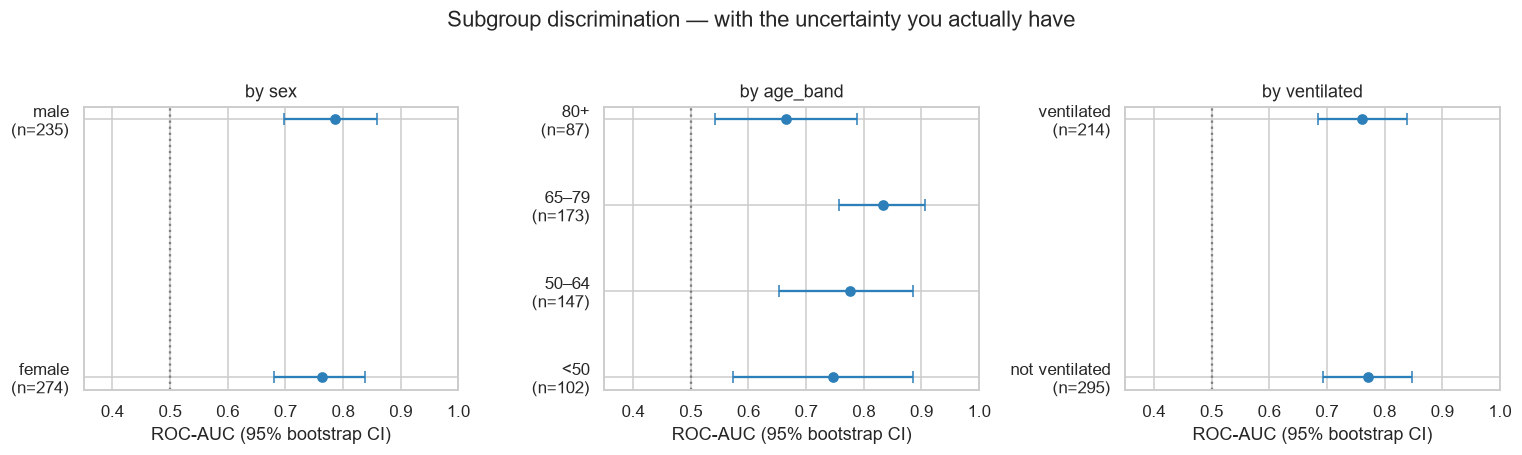

In [7]:
rng = np.random.default_rng(RANDOM_STATE)
N_BOOT = 500

def boot_auc_ci(df, by, n_boot=N_BOOT):
    out = {}
    for name, g in df.groupby(by, observed=True):
        if g["morta_90"].nunique() < 2 or len(g) < 20:
            continue
        yv, pv = g["morta_90"].to_numpy(), g["risk"].to_numpy()
        aucs = []
        for _ in range(n_boot):
            i = rng.integers(0, len(g), len(g))
            if len(np.unique(yv[i])) < 2:
                continue
            aucs.append(roc_auc_score(yv[i], pv[i]))
        out[str(name)] = (np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5), len(g))
    return out

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, by in zip(axes, ["sex", "age_band", "ventilated"]):
    ci = boot_auc_ci(test, by)
    names = list(ci)
    means = [ci[n][0] for n in names]
    lo = [ci[n][0] - ci[n][1] for n in names]
    hi = [ci[n][2] - ci[n][0] for n in names]
    ax.errorbar(means, range(len(names)), xerr=[lo, hi], fmt="o", capsize=4, color="#2c7fb8")
    ax.axvline(0.5, ls=":", c="grey"); ax.set_yticks(range(len(names)))
    ax.set_yticklabels([f"{n}\n(n={ci[n][3]})" for n in names])
    ax.set_xlim(0.35, 1.0); ax.set_xlabel("ROC-AUC (95% bootstrap CI)"); ax.set_title(f"by {by}")
plt.suptitle("Subgroup discrimination — with the uncertainty you actually have", y=1.03)
plt.tight_layout(); plt.show()

**If the intervals overlap, you do not have evidence of a performance gap.** Say that out loud.
Reporting "AUC 0.81 in men vs 0.75 in women" without the CIs is one of the most common ways
fairness analyses mislead — in both directions.

## 🎯 Step 5 — calibration by subgroup

Discrimination asks *"can you rank?"*. Calibration asks *"does 20% mean 20%?"* — which is the
question a clinician acting on the number actually needs answered.

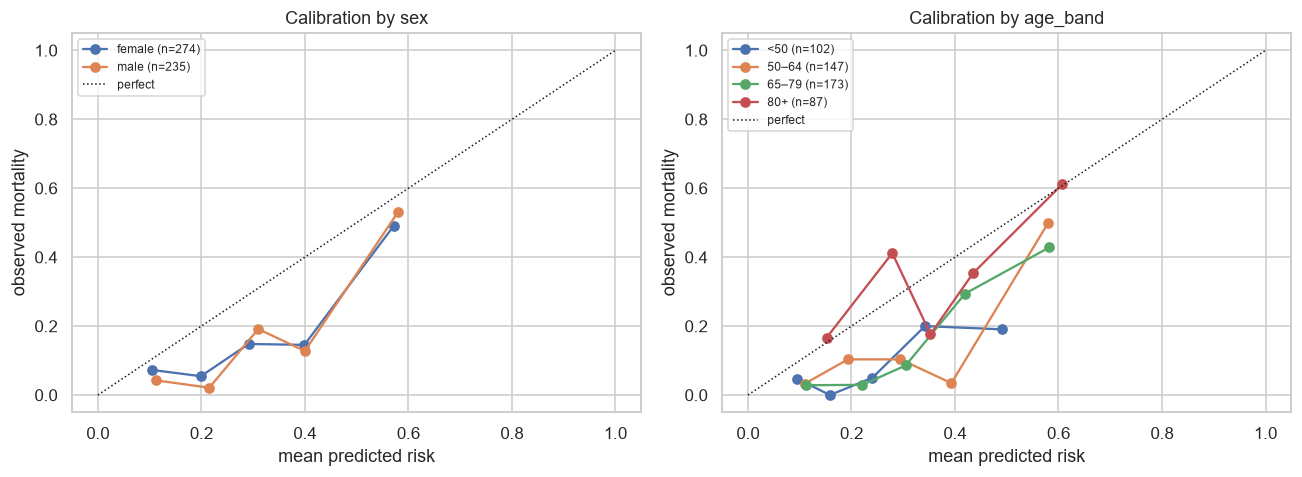

In [8]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, by in zip(axes, ["sex", "age_band"]):
    for name, g in test.groupby(by, observed=True):
        if len(g) < 60 or g["morta_90"].nunique() < 2:
            continue
        n_bins = 5
        frac, mean_pred = calibration_curve(g["morta_90"], g["risk"], n_bins=n_bins, strategy="quantile")
        ax.plot(mean_pred, frac, "o-", label=f"{name} (n={len(g)})")
    ax.plot([0, 1], [0, 1], "k:", lw=1, label="perfect")
    ax.set_xlabel("mean predicted risk"); ax.set_ylabel("observed mortality")
    ax.set_title(f"Calibration by {by}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

A curve sitting **below** the diagonal means the model **over-predicts** risk for that group —
they get alarms they didn't need. **Above** the diagonal means it **under-predicts** — the group is
sicker than the model thinks, and they get missed. The second is the one that kills people.

## ⚙️ Step 6 — the uncomfortable trade-off: equalising sensitivity

Suppose one subgroup has lower sensitivity at the shared 0.50 threshold. The obvious fix is to
**lower the threshold for that group**. Let's do it and look at what it costs.

In [9]:
def threshold_for_sensitivity(g, target_sens):
    """Lowest risk cut-off that reaches `target_sens` in this subgroup."""
    for t in np.arange(0.95, 0.0, -0.01):
        if recall_score(g["morta_90"], (g["risk"] >= t).astype(int), zero_division=0) >= target_sens:
            return round(float(t), 2)
    return 0.0

by = "age_band"
base = subgroup_report(test, by)
target = base["sensitivity"].max()          # match the best-served group
print(f"Target sensitivity (best-served group): {target:.2f}\n")

rows = []
for name, g in test.groupby(by, observed=True):
    if len(g) < 20 or g["morta_90"].nunique() < 2:
        continue
    t = threshold_for_sensitivity(g, target)
    flag = (g["risk"] >= t).astype(int)
    rows.append({by: str(name), "threshold": t,
                 "sensitivity": recall_score(g["morta_90"], flag, zero_division=0),
                 "PPV": precision_score(g["morta_90"], flag, zero_division=0),
                 "alert_rate": flag.mean(),
                 "alerts_per_death_caught": flag.sum() / max(1, (flag & (g["morta_90"] == 1)).sum())})
print(pd.DataFrame(rows).set_index(by).round(3).to_string())

Target sensitivity (best-served group): 0.57



          threshold  sensitivity    PPV  alert_rate  alerts_per_death_caught
age_band                                                                    
<50            0.37        0.600  0.250       0.235                    4.000
50–64          0.54        0.565  0.650       0.136                    1.538
65–79          0.46        0.600  0.474       0.220                    2.111
80+            0.39        0.567  0.472       0.414                    2.118


### The lesson

Equalising **sensitivity** forces the threshold down in every group that was lagging — which drives
their **alert rate** up and, generally, their **PPV** down. You have moved the harm, not removed it:
those groups now get more false alarms, and false alarms cause alarm fatigue, unnecessary tests and
unnecessary transfers.

Look at the last column, **`alerts_per_death_caught`** — that is the number your ICU actually feels.
Equal sensitivity is bought at a very unequal price per group.

This is not a bug in the analysis. It is a **theorem**: when base rates differ between groups, you
cannot simultaneously have equal sensitivity, equal PPV and equal calibration
(Kleinberg et al. 2016; Chouldechova 2017). **You must choose which one to equalise, and justify it
clinically.** "We optimised fairness" is not a sentence a fairness expert would ever write.

## ✏️ Your turn

1. Re-run the subgroup report at `THRESHOLD = 0.25` instead of 0.50. Which gaps grow, which shrink?
2. Add a subgroup of your own — e.g. `re_admission`, or a `elixhauser`-based comorbidity band.
3. Does dropping `age` from the feature list *reduce* the age-band gap, or just make the model worse
   for everyone? (This is the "fairness through unawareness" fallacy — test it, don't assume it.)

<details>
<summary>💡 Show solution for 3</summary>

```python
FEATURES_NO_AGE = [c for c in FEATURES if c != "age"]
m2 = Pipeline([("impute", SimpleImputer(strategy="median")),
               ("rf", RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                             class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1))])
m2.fit(pat.loc[idx_train, FEATURES_NO_AGE], y.loc[idx_train])
t2 = pat.loc[idx_test].copy()
t2["risk"] = m2.predict_proba(pat.loc[idx_test, FEATURES_NO_AGE])[:, 1]
print("with age:"); print(subgroup_report(test, "age_band")[["AUC", "sensitivity"]].round(3))
print("without age:"); print(subgroup_report(t2, "age_band")[["AUC", "sensitivity"]].round(3))
```

Typically the gaps **do not disappear** — age is reconstructible from the other physiology — while
overall performance drops. Removing a protected attribute usually makes a model *less* accountable,
not fairer, because you can no longer measure the gap you created.
</details>

## 📋 What to put in your paper

A reusable checklist — this is roughly what TRIPOD+AI and most journals now expect:

- [ ] **Cohort composition** per subgroup (n, events, base rate) — before any model output.
- [ ] **Per-subgroup discrimination and calibration**, each with a confidence interval.
- [ ] **Performance at the deployed threshold**, not just AUC — sensitivity, PPV, alert rate.
- [ ] Which fairness criterion you chose to prioritise, and the **clinical justification**.
- [ ] Subgroups you **could not** evaluate because n was too small — name them; silence reads as
      "we checked and it was fine".
- [ ] Whether protected attributes were used as features, and why.
- [ ] Known **data-collection** biases: who gets a lactate drawn, who gets an arterial line, who is
      admitted to ICU at all. A model learns the ordering behaviour, not just the biology.

## 🔑 Take-home

> **An average is a promise you make to a population, not to a patient.**
> Report per subgroup, report uncertainty, and state which fairness criterion you traded away.

## 📚 Further reading
- Chouldechova, *Fair prediction with disparate impact*, 2017 — the impossibility result.
- Kleinberg, Mullainathan & Raghavan, *Inherent trade-offs in fair determination of risk scores*, 2016.
- Obermeyer et al., *Dissecting racial bias in an algorithm used to manage the health of populations*,
  **Science** 2019 — the canonical clinical example (the label itself was biased).
- Collins et al., **TRIPOD+AI** (BMJ 2024) — reporting standard for clinical prediction models.

<!-- nav-footer -->
---

### ➡️ Next up — Notebook 14: Capstone challenge

<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/14_capstone_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook 14 in Colab" height="32"/></a>

👉 **[Continue to Notebook 14 — Capstone challenge](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/14_capstone_challenge.ipynb)**

[⬅ Back to Notebook 12](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/12_big_data_beyond_pandas.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [📁 The course on GitHub](https://github.com/lorenzkap/ML2026)